In [25]:
#IMPORTING PACKAGES

import pandas as pd
import numpy as np
import pickle

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE


In [32]:
#DATA LOADING

df = pd.read_csv("D:\Guvi-Projects\Project 3\Employee-Attrition - Employee-Attrition.csv")
df.shape


<>:3: SyntaxWarning: invalid escape sequence '\G'
<>:3: SyntaxWarning: invalid escape sequence '\G'
C:\Users\Akash Subramanian\AppData\Local\Temp\ipykernel_20908\1548742207.py:3: SyntaxWarning: invalid escape sequence '\G'
  df = pd.read_csv("D:\Guvi-Projects\Project 3\Employee-Attrition - Employee-Attrition.csv")


(1470, 35)

In [5]:
#SELECT REQUIRED COLUMNS
attrition_numeric = [
    'Age', 'MonthlyIncome', 'DistanceFromHome', 'TotalWorkingYears',
    'YearsAtCompany', 'YearsInCurrentRole', 'PercentSalaryHike',
    'JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance'
]

attrition_categorical = [
    'OverTime', 'Gender', 'JobRole', 'MaritalStatus', 'BusinessTravel'
]

target_col = 'Attrition'

df_attr = df[attrition_numeric + attrition_categorical + [target_col]].copy()


In [6]:
#CHECKING NULL VALUES

df_attr.isnull().sum()

Age                        0
MonthlyIncome              0
DistanceFromHome           0
TotalWorkingYears          0
YearsAtCompany             0
YearsInCurrentRole         0
PercentSalaryHike          0
JobSatisfaction            0
EnvironmentSatisfaction    0
WorkLifeBalance            0
OverTime                   0
Gender                     0
JobRole                    0
MaritalStatus              0
BusinessTravel             0
Attrition                  0
dtype: int64

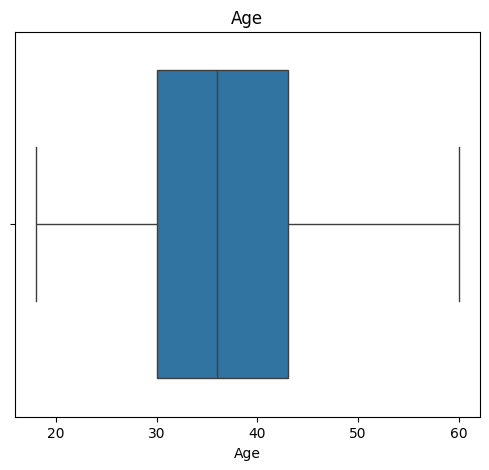

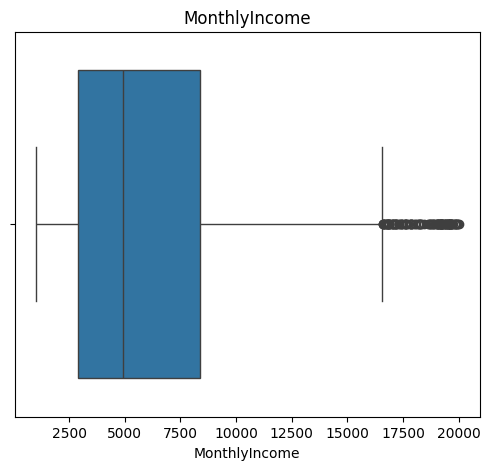

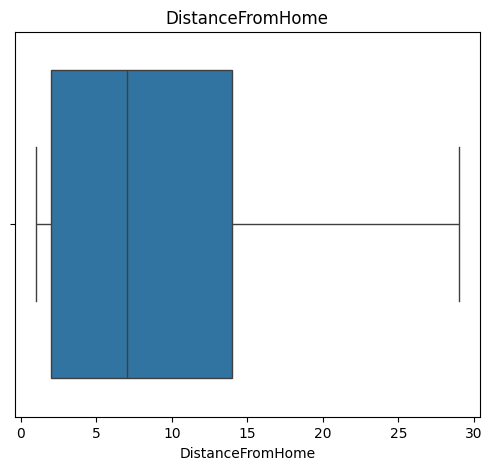

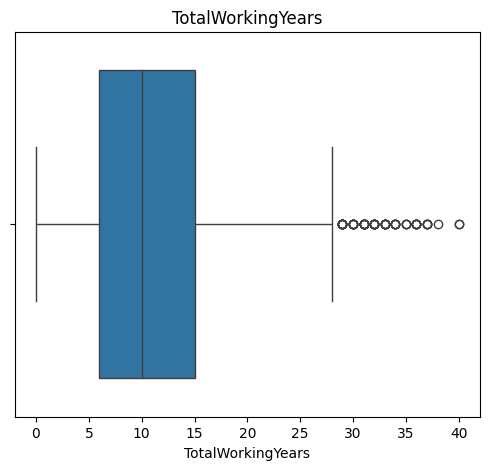

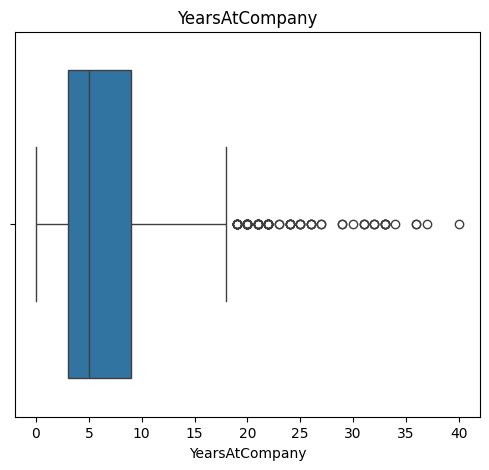

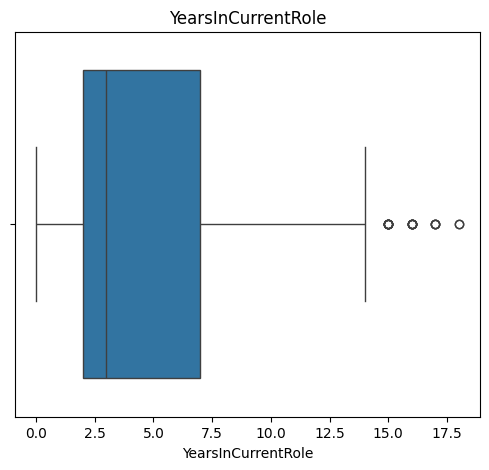

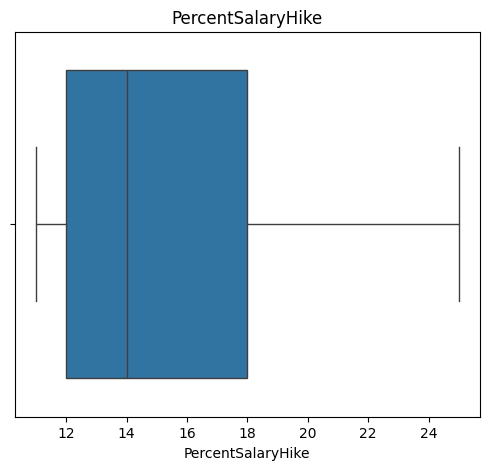

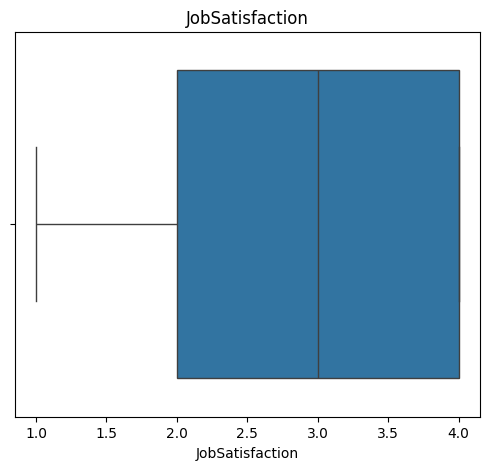

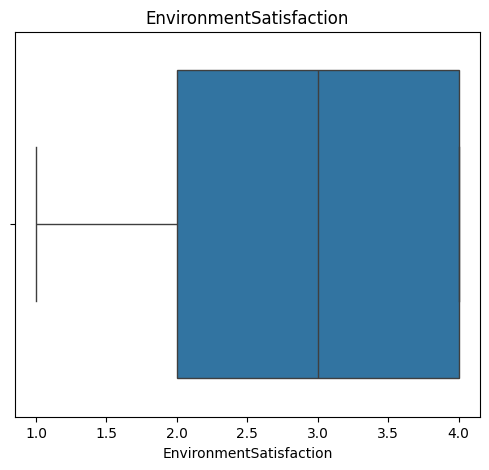

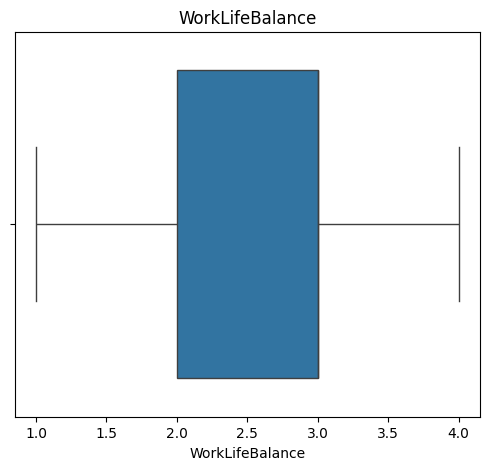

In [11]:
#CHECKING OUTLIER USING BOX PLOT

for col in attrition_numeric:
    plt.figure(figsize=(6,5))
    sns.boxplot(x=df_attr[col])
    plt.title(col)
    plt.show()


In [12]:
#HANDLING OUTLIERS

for col in attrition_numeric:
    Q1 = df_attr[col].quantile(0.25)
    Q3 = df_attr[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_attr[col] = np.where(df_attr[col] < lower, lower, df_attr[col])
    df_attr[col] = np.where(df_attr[col] > upper, upper, df_attr[col])


In [14]:
#ENCODING 

df_attr['Attrition'] = df_attr['Attrition'].map({'No': 0, 'Yes': 1})
df_attr['OverTime'] = df_attr['OverTime'].map({'No': 0, 'Yes': 1})
df_attr['Gender'] = df_attr['Gender'].map({'Female': 0, 'Male': 1})

df_attr['BusinessTravel'] = df_attr['BusinessTravel'].map({
    'Non-Travel': 0,
    'Travel_Rarely': 1,
    'Travel_Frequently': 2
})

df_attr['MaritalStatus'] = df_attr['MaritalStatus'].map({
    'Single': 0,
    'Married': 1,
    'Divorced': 2
})

df_attr['JobRole'] = df_attr['JobRole'].astype('category').cat.codes


In [17]:
display(df_attr)

,Age,MonthlyIncome,DistanceFromHome,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,PercentSalaryHike,JobSatisfaction,EnvironmentSatisfaction,WorkLifeBalance,OverTime,Gender,JobRole,MaritalStatus,BusinessTravel,Attrition
0,41.0,5993.0,1.0,8.0,6.0,4.0,11.0,4.0,2.0,1.0,1,0,7,0,1,1
1,49.0,5130.0,8.0,10.0,10.0,7.0,23.0,2.0,3.0,3.0,0,1,6,1,2,0
2,37.0,2090.0,2.0,7.0,0.0,0.0,15.0,3.0,4.0,3.0,1,1,2,0,1,1
3,33.0,2909.0,3.0,8.0,8.0,7.0,11.0,3.0,4.0,3.0,1,0,6,1,2,0
4,27.0,3468.0,2.0,6.0,2.0,2.0,12.0,2.0,1.0,3.0,0,1,2,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36.0,2571.0,23.0,17.0,5.0,2.0,17.0,4.0,3.0,3.0,0,1,2,1,2,0
1466,39.0,9991.0,6.0,9.0,7.0,7.0,15.0,1.0,4.0,3.0,0,1,0,1,1,0
1467,27.0,6142.0,4.0,6.0,6.0,2.0,20.0,2.0,2.0,3.0,1,1,4,1,1,0
1468,49.0,5390.0,2.0,17.0,9.0,6.0,14.0,2.0,4.0,2.0,0,1,7,1,2,0


In [18]:
#FEATURE SELECTION

X = df_attr.drop(columns=['Attrition'])
y = df_attr['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [19]:
#HANDLING IMBALANCE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(y_train_res.value_counts())


After SMOTE:
Attrition
0    986
1    986
Name: count, dtype: int64


In [20]:
#SCALING USING STANDARD SCALER

scaler_attr = StandardScaler()

X_train_res[attrition_numeric] = scaler_attr.fit_transform(
    X_train_res[attrition_numeric]
)

X_test[attrition_numeric] = scaler_attr.transform(
    X_test[attrition_numeric]
)

pickle.dump(scaler_attr, open("attrition_scaler.pkl", "wb"))


In [29]:
#LOGISTIC REGRESSION

attrition_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

attrition_model.fit(X_train_res, y_train_res)

prob = attrition_model.predict_proba(X_test)[:, 1]
y_pred = (prob >= 0.4).astype(int)

print("Attrition Accuracy:", accuracy_score(y_test, y_pred))
print(pd.Series(y_pred).value_counts())


Attrition Accuracy: 0.6326530612244898
0    163
1    131
Name: count, dtype: int64


In [23]:
#KNN

knn = KNeighborsClassifier(
    n_neighbors=9,      # 7–11 sweet spot
    weights='distance', # important
    metric='minkowski'
)

knn.fit(X_train_res, y_train_res)

y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


KNN Accuracy: 0.608843537414966
              precision    recall  f1-score   support

           0       0.87      0.63      0.73       247
           1       0.20      0.49      0.29        47

    accuracy                           0.61       294
   macro avg       0.53      0.56      0.51       294
weighted avg       0.76      0.61      0.66       294



In [24]:
#DECISION TREE

dt = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=7,           # critical
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)

dt.fit(X_train_res, y_train_res)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


Decision Tree Accuracy: 0.7857142857142857
              precision    recall  f1-score   support

           0       0.87      0.88      0.87       247
           1       0.31      0.28      0.29        47

    accuracy                           0.79       294
   macro avg       0.59      0.58      0.58       294
weighted avg       0.78      0.79      0.78       294



In [28]:
#RANDOM FOREST

rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train_res, y_train_res)
y_pred_base = rf.predict(X_test)

print("Base RF Accuracy:", accuracy_score(y_test, y_pred_base))

Base RF Accuracy: 0.8231292517006803


In [30]:
import pickle

pickle.dump(rf, open("attrition_model.pkl", "wb"))


In [ ]:
# =====================================================
#PROMOTION PREDICTION
# =====================================================

In [33]:
#cREATE PROMOTION TARGET

df['Promotion'] = df['YearsSinceLastPromotion'].apply(
    lambda x: 1 if x == 0 else 0
)


#SELECTED COLUMNS

promo_features = [
    'PerformanceRating',
    'YearsAtCompany',
    'YearsInCurrentRole',
    'TotalWorkingYears',
    'JobInvolvement',
    'JobSatisfaction',
    'EnvironmentSatisfaction',
    'TrainingTimesLastYear',
    'MonthlyIncome',
    'JobLevel'
]

target_promo = 'Promotion'

df_promo = df[promo_features + [target_promo]].copy()


#FEATURE AND TARGET SELECTION

X = df_promo[promo_features]
y = df_promo[target_promo]

#TRAIN_TEST_SPLIT
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


#HANDLE IMBALANCEING

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(y_train_res.value_counts())


#SCALING

from sklearn.preprocessing import StandardScaler

scaler_promo = StandardScaler()

X_train_scaled = scaler_promo.fit_transform(X_train_res)
X_test_scaled = scaler_promo.transform(X_test)

#MODEL - DECISION TREE

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

promo_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=8,
    min_samples_split=15,
    min_samples_leaf=8,
    class_weight='balanced',
    random_state=42
)

promo_model.fit(X_train_scaled, y_train_res)

#PREDICTION AND ACCURAY

y_pred = promo_model.predict(X_test_scaled)

print("Promotion Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

#SAVE MODEL AND SCALER

import pickle

pickle.dump(promo_model, open("promotion_model.pkl", "wb"))
pickle.dump(scaler_promo, open("promotion_scaler.pkl", "wb"))




After SMOTE:
Promotion
1    711
0    711
Name: count, dtype: int64
Promotion Accuracy: 0.7142857142857143

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.72      0.75       178
           1       0.62      0.70      0.66       116

    accuracy                           0.71       294
   macro avg       0.70      0.71      0.71       294
weighted avg       0.72      0.71      0.72       294



In [ ]:
# =====================================================
# PERFORMANCE PREDICTION
# =====================================================

In [ ]:

# SELECT REQUIRED COLUMNS

perf_features = [
    'Education',
    'JobInvolvement',
    'JobLevel',
    'MonthlyIncome',
    'YearsAtCompany',
    'YearsInCurrentRole'
]

target_perf = 'PerformanceRating'

df_perf = df[perf_features + [target_perf]].copy()

# FEATURE AND TARGET SELECTION

X = df_perf[perf_features]
y = df_perf[target_perf]


# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# SCALING (IMPORTANT FOR LINEAR REGRESSION)

scaler_perf = StandardScaler()

X_train_scaled = scaler_perf.fit_transform(X_train)
X_test_scaled = scaler_perf.transform(X_test)

# MODEL - LINEAR REGRESSION

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

perf_model = LinearRegression()

perf_model.fit(X_train_scaled, y_train)


# PREDICTION AND EVALUATION

y_pred = perf_model.predict(X_test_scaled)

print("R2 Score:", r2_score(y_test, y_pred))

rmse = mean_squared_error(y_test, y_pred) ** 0.5
print("RMSE:", rmse)

# OPTIONAL: ACCURACY FOR DEMO (ROUNDED)

import numpy as np
from sklearn.metrics import accuracy_score

y_pred_round = np.round(y_pred)
print("Performance Accuracy (Rounded):", accuracy_score(y_test, y_pred_round))

# SAVE MODEL AND SCALER

import pickle

pickle.dump(perf_model, open("performance_model.pkl", "wb"))
pickle.dump(scaler_perf, open("performance_scaler.pkl", "wb"))

R2 Score: 0.004657866951130352
RMSE: 0.3525412598941673
Performance Accuracy (Rounded): 0.8537414965986394
